In [1]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from netCDF4 import Dataset

import iris
import iris.coord_categorisation
import iris.plot as iplt
import iris.quickplot as qplt

import os
import logging

import numpy as np
import numpy.ma as ma

import pickle
from pathlib import Path

from IPython.display import clear_output
import gc

logger = logging.getLogger(__name__)

In [2]:
run plot_tools.ipynb

read pickle files /bdd/ESM2025/WP10/analysis/files/driving_datacheck_tas.pkl
ssp126 mpi-esm1-2-hr_r1i1p1f1 Avg change in tas by 2040-2059: 0.4145543926015307 and by 2081-2100: 0.33852206426223574 compared to 2015-2034
Std deviation from 2015-2034: 0.19098140741312042 from 2040-2059: 0.11309389955591538 and from 2081-2100: 0.15510397179380847
ssp126 ukesm1-0-ll_r1i1p1f2 Avg change in tas by 2040-2059: 1.0322125218157794 and by 2081-2100: 1.5190163028756274 compared to 2015-2034
Std deviation from 2015-2034: 0.3640575784250311 from 2040-2059: 0.24590956156308688 and from 2081-2100: 0.1607205568038043
ssp126 ipsl-cm6a-lr_r1i1p1f1 Avg change in tas by 2040-2059: 0.7682027009839203 and by 2081-2100: 0.9270193793053636 compared to 2015-2034
Std deviation from 2015-2034: 0.2592478454898427 from 2040-2059: 0.2509372195534439 and from 2081-2100: 0.15867060025979265
ssp370 mpi-esm1-2-hr_r1i1p1f1 Avg change in tas by 2040-2059: 0.8953768720091944 and by 2081-2100: 2.607557250028151 compared to 20

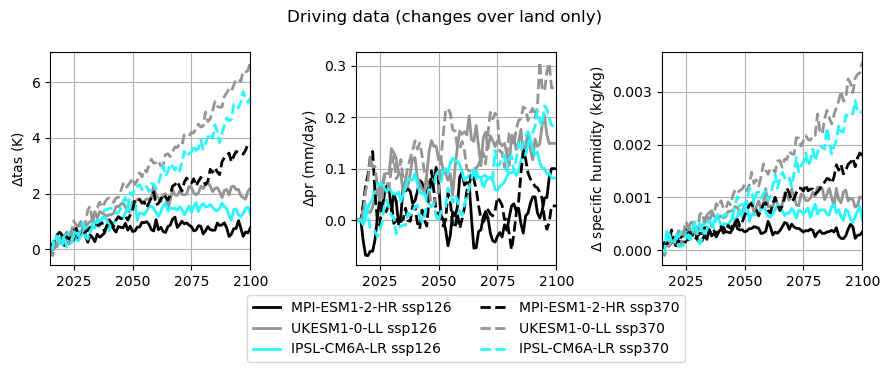

In [4]:
SSPS=['ssp126','ssp370']
ESMS=['mpi-esm1-2-hr_r1i1p1f1','ukesm1-0-ll_r1i1p1f2','ipsl-cm6a-lr_r1i1p1f1']
ESM_title=['MPI-ESM1-2-HR','UKESM1-0-LL','IPSL-CM6A-LR']
VARIABLES=['tas','pr','huss']
nESMS=len(ESMS)

years = np.arange(2015,2101)     
nyears = len(years)

VAR_MEAN = {var: {ssp_scen: {esm: [] for esm in ESMS} for ssp_scen in SSPS} for var in VARIABLES}

land_frac = iris.load_cube('/bdd/ESM2025/WP10/analysis/scripts/mask_latlon2d.nc','land_sea_mask')
land_frac.standard_name='land_area_fraction' #Note this does not include Antarctica but it doesn include Greenland.
land_points = (land_frac.core_data() > 0).astype(int)

#land_sea_mask = np.ma.masked_values(land_frac.core_data(), 0)
#print(land_sea_mask)
#print(np.min(land_sea_mask),np.max(land_sea_mask))


#Set up plotting stuff
#Each ESM needs a different color
fig,axes=plt.subplots(1,3, figsize=[9,3])
fig.suptitle('Driving data (changes over land only)',fontsize=12)
ix=0

colors = {model: [] for model in ESMS}
colors['ukesm1-0-ll_r1i1p1f2'] = 'xkcd:grey'
colors['mpi-esm1-2-hr_r1i1p1f1'] = 'xkcd:black'
colors['ipsl-cm6a-lr_r1i1p1f1'] = 'xkcd:bright light blue'
#https://matplotlib.org/stable/users/explain/colors/colors.html

linestyles = {ssp: [] for ssp in SSPS}
linestyles['ssp126'] = '-'
linestyles['ssp370'] = '--'

for var in VARIABLES:
    # set axes
    ax=axes[ix]
    if var=='tas': ax.set_ylabel(r'$\Delta$' +var+' (K)',fontsize=10)
    if var=='pr': ax.set_ylabel(r'$\Delta$' +var+' (mm/day)',fontsize=10)
    if var=='huss': ax.set_ylabel(r'$\Delta$ specific humidity (kg/kg)',fontsize=10)
    ax.set_xlim([2015,2100])
    ax.grid(True) 

    my_file = Path('/bdd/ESM2025/WP10/analysis/files/driving_datacheck_'+var+'.pkl')    
    if my_file.is_file():
        # file exists, we can skip a bunch of steps:
        print('read pickle files',my_file)
        with open(my_file, 'rb') as f1:
            VAR_MEAN[var] = pickle.load(f1)    
    
    else:
        for ssp in SSPS:
            for esm in ESMS:
                dir='/homedata/elittle/InputData/2deg/climate/'
                filenames=[dir+esm+'_w5e5_'+ssp+'_'+var+'_global_daily_2015_2020.nc',
                           dir+esm+'_w5e5_'+ssp+'_'+var+'_global_daily_2021_2030.nc',
                           dir+esm+'_w5e5_'+ssp+'_'+var+'_global_daily_2031_2040.nc',
                           dir+esm+'_w5e5_'+ssp+'_'+var+'_global_daily_2041_2050.nc',
                           dir+esm+'_w5e5_'+ssp+'_'+var+'_global_daily_2051_2060.nc',
                           dir+esm+'_w5e5_'+ssp+'_'+var+'_global_daily_2061_2070.nc',
                           dir+esm+'_w5e5_'+ssp+'_'+var+'_global_daily_2071_2080.nc',
                           dir+esm+'_w5e5_'+ssp+'_'+var+'_global_daily_2081_2090.nc',
                           dir+esm+'_w5e5_'+ssp+'_'+var+'_global_daily_2091_2100.nc']

                for fname in filenames:
                    # Each cube here has time (days*years), lat, lon
                    cubes = iris.load(fname)
                    esm_cube=cubes[0]
                
                    # Steps: 1) apply a 2deg land/sea mask
                    #        2) calculate the global mean for that time period
                    #        3) append the time series onto the end of the relevant dictionary.

                    add_ancillary_variable(esm_cube,land_frac)
                
                    try:
                        latcoord = esm_cube.coord("latitude")
                    except:
                        latcoord = esm_cube.coord("lat")
                    latcoord.units="degrees"
                    try:
                        loncoord = esm_cube.coord("longitude")
                    except:
                        loncoord = esm_cube.coord("lon")
                    loncoord.units="degrees"                  
                    iris.coord_categorisation.add_year(esm_cube,'time',name='year')        

                    weighting_landsea_fraction(esm_cube, 'land', apply_mask_only=True)
                    #print(np.ma.count_masked(esm_cube.data))
                    # Step 1) calculate the annual means
                    cveg_annual_map = esm_cube.aggregated_by('year',iris.analysis.MEAN)

                    # Step 2) Mask out ocean points
                    cveg_annual_map.coord("latitude").guess_bounds()
                    cveg_annual_map.coord("longitude").guess_bounds()
                
                    grid_areas = iris.analysis.cartography.area_weights(cveg_annual_map,normalize=False)
    
                    # Step 3) Calculate global means
                    constant_val=1.0
                    iris.util.mask_cube(cveg_annual_map,land_points)
                    cveg_global = (cveg_annual_map.collapsed(["latitude","longitude"], 
                                   iris.analysis.MEAN, weights=grid_areas)/constant_val)
                
                    # Step 4) Append the time series onto the end of the relevant dictionary
                    cveg_global.data
                    for item in cveg_global.core_data():
                        VAR_MEAN[var][ssp][esm].append(item)                     
                    
                    del(cveg_global,cveg_annual_map)

                #print('annual means:')
                #print(VAR_MEAN[var][ssp][esm])

        
        with open(my_file, 'wb') as f:
            pickle.dump(VAR_MEAN[var], f)
    
    for ssp in SSPS:
        for i0 in range(nESMS):
            esm=ESMS[i0]
            
            plot_var_temp = np.array(VAR_MEAN[var][ssp][esm])
            if var=='pr':
                plot_var_temp=86400*plot_var_temp
                plot_var[0]=np.mean(plot_var_temp[0:5])
                plot_var[1]=np.mean(plot_var_temp[0:5])
                plot_var[2]=np.mean(plot_var_temp[0:5])
                for n in range(2,nyears-2):
                    plot_var[n] = np.mean(plot_var_temp[n-2:n+3])
                plot_var[nyears-2]=np.mean(plot_var_temp[nyears-5:nyears])
                plot_var[nyears-1]=np.mean(plot_var_temp[nyears-5:nyears])
            else:
                plot_var=plot_var_temp
            # Print avg(2081-2100) - avg(2015-2034) since this is what's shown in the maps
            print(ssp,esm,'Avg change in',var,'by 2040-2059:',\
                  np.mean(plot_var[25:45])-np.mean(plot_var[0:20]),\
                  'and by 2081-2100:',np.mean(plot_var[65:85])-np.mean(plot_var[0:20]),\
                  'compared to 2015-2034')
            print('Std deviation from 2015-2034:',np.std(plot_var[0:20]),\
                  'from 2040-2059:',np.std(plot_var[25:45]),\
                  'and from 2081-2100:',np.std(plot_var[65:85]))
#              plot_diff=(VAR_MEAN[var][ssp][esm]) - (VAR_MEAN[var][ssp][esm])[0]
            ax.plot(years, plot_var-plot_var[0], label=ESM_title[i0]+' '+ssp,
                            c=colors[esm],ls=linestyles[ssp],lw=2)

    ix+=1


handles,labels = ax.get_legend_handles_labels()
lgd=fig.legend(handles,labels,ncol=2,loc='upper left',bbox_to_anchor=(0.28, 0.03),fontsize=10,borderaxespad=0.)
fig.tight_layout()

plt.savefig('/bdd/ESM2025/WP10/plots/climate_data.png', dpi=400,bbox_extra_artists=(lgd,), bbox_inches='tight',format="png")

    

In [ ]:
def generate_plot(variable, iESM, ssp, mapdata, plotrow,plotcolumn,mask_above,
                                 mask_below,mask_between,treshold):
    
    # 111 means 1 row, 1 col and index 1
    ax = axes[plotrow,plotcolumn]

    if var=='tas':
        if ssp=='ssp126':
            cbarticks = np.arange(-3.0,3.5,0.5)
            contourmin = -3.0
            contourmax = 3.0
        else:
            cbarticks = np.arange(-8.0,9.0,1.0)
            contourmin = -8.0
            contourmax = 8.0            
        colormap = 'RdBu_r' # red numbers higher
        if mask_above:
            mask_above_threshold(mapdata, threshold)
        if mask_below:
            mask_below_threshold(mapdata, threshold)
        if mask_between:
            mask_between_threshold(mapdata, threshold)
            
    elif var=='pr':
        if ssp=='ssp126':
            contourmin = -1.0
            contourmax = 1.0
            cbarticks = np.arange(-1.1,1.1,0.1)
        else:
            contourmin = -1.5
            contourmax = 1.5
            cbarticks = np.arange(-1.5,1.75,0.25)
            
        colormap = 'RdBu' # blue numbers higher
        if mask_above:
            mask_above_threshold(mapdata, threshold)
        if mask_below:
            mask_below_threshold(mapdata, threshold)
        if mask_between:
            mask_between_threshold(mapdata, threshold)

    
    elif var=='huss':
        contourmin = -0.003
        contourmax = 0.003
        cbarticks = np.arange(-0.003,0.0035,0.0005)
        colormap = 'RdBu' # blue numbers higher

    latSouth=0
    latNorth=89
    clon=0.0  
    fig = iplt.contourf(mapdata[latSouth:latNorth,:], cbarticks, cmap=colormap, vmin = contourmin, 
                        vmax = contourmax, extend="both",axes=ax,
                        coords=[mapdata.coord("longitude"),mapdata.coord("latitude")[latSouth:latNorth]])
    ax.coastlines()
    ax.set_title(ESM_title[iESM]+' '+ssp)
    #cbar = fig.colorbar(cs, shrink=0.6,ticks=cbarticks, orientation="vertical")
    #cbar.ax.set_xlabel("PgC")

    return (ax,fig)

In [ ]:
# Useful bit of code from https://docs.esmvaltool.org/projects/ESMValCore/en/v2.5.0rc2/_modules/esmvalcore/preprocessor/_mask.html
def mask_above_threshold(cube, threshold):
    """Mask above a specific threshold value.

    Takes a value 'threshold' and masks off anything that is above
    it in the cube data. Values equal to the threshold are not masked.

    Parameters
    ----------
    cube: iris.cube.Cube
        iris cube to be thresholded.

    threshold: float
        threshold to be applied on input cube data.

    Returns
    -------
    iris.cube.Cube
        thresholded cube.
    """
    cube.data = np.ma.masked_where(cube.data > threshold, cube.data)
    return cube

def mask_between_threshold(cube, threshold):
    """Mask values between +/- a specific threshold value.

    Takes a value 'threshold' and masks off anything that is above
    it in the cube data. Values equal to the threshold are not masked.

    Parameters
    ----------
    cube: iris.cube.Cube
        iris cube to be thresholded.

    threshold: float
        threshold to be applied on input cube data.

    Returns
    -------
    iris.cube.Cube
        thresholded cube.
    """
    negative_threshold = -1 * threshold
    cube.data = np.ma.masked_inside(cube.data, negative_threshold, threshold)
    return cube



def mask_below_threshold(cube, threshold):
    """Mask below a specific threshold value.

    Takes a value 'threshold' and masks off anything that is below
    it in the cube data. Values equal to the threshold are not masked.

    Parameters
    ----------
    cube: iris.cube.Cube
        iris cube to be thresholded
    threshold: float
        threshold to be applied on input cube data.

    Returns
    -------
    iris.cube.Cube
        thresholded cube.
    """
    cube.data = np.ma.masked_where(cube.data < threshold, cube.data)
    return cube

In [ ]:
for var in VARIABLES[1:2]:

    fig,axes=plt.subplots(2,3, figsize=[9,6],subplot_kw={'projection': ccrs.Robinson(central_longitude=0)})

    plotrow=0
    plotcolumn=0
    for ssp in SSPS:
        for i0 in range(nESMS):
            esm=ESMS[i0]
            f1='/bdd/ESM2025/WP10/analysis/driving_data/'+esm+'_'+ssp+'_'+var+'-2015-2034avg.nc'
            f2='/bdd/ESM2025/WP10/analysis/driving_data/'+esm+'_'+ssp+'_'+var+'-2081-2100avg.nc'
            
            cube1=iris.load(f1)
            cube2=iris.load(f2)
            #print(cube1)
            #print(cube2)
            add_ancillary_variable(cube1[0],land_frac)
            add_ancillary_variable(cube2[0],land_frac)
            weighting_landsea_fraction(cube1[0], 'land', apply_mask_only=False)
            weighting_landsea_fraction(cube2[0], 'land', apply_mask_only=False)
            

            diff=cube2[0][0,]-cube1[0][0,]
            #print(diff)
            if var=='pr':
                diff=86400*diff
            threshold=0.000001
            mask_below=False
            mask_above=False
            mask_between=True
            if plotrow==0:
                ax1,cs1 = generate_plot(var,i0,ssp,diff,plotrow,plotcolumn,mask_above,
                                     mask_below,mask_between,threshold)
            else:
                ax2,cs2 = generate_plot(var,i0,ssp,diff,plotrow,plotcolumn,mask_above,
                                     mask_below,mask_between,threshold)                
            # Problem with temperature mapping - I have to set this threshold or else
            # it maps Antarctica
            #if plotcolumn==1:
            
                #fig.colorbar(cs, shrink=0.9, orientation='horizontal', ax=ax,label='mm d$^{-1}$')
                
            plotcolumn+=1
            if plotcolumn>2:
                
                #https://matplotlib.org/stable/users/explain/axes/colorbar_placement.html
                #fig.colorbar(cs, ax=axes[plotrow,:], shrink=0.4, location='bottom',orientation='horizontal', 
                #             label=r'$\Delta$pr (mm d$^{-1}$)')
                #fig.colorbar(cs, ax=axes[plotrow,:], shrink=0.4, location='bottom',orientation='horizontal', 
                #             label=r'$\Delta$tas (K)')
                plotcolumn=0
                plotrow+=1
                #fig.colorbar(cs, shrink=0.6, orientation='horizontal', ax=axes.ravel().tolist(),label='K')


            #Clear up memory!
            del(cube1,cube2)

    plt.subplots_adjust(wspace=0.1, hspace=0.05)
    if var=='tas':
        label=r'$\Delta$tas (K)'
    elif var=='pr':
        label=r'$\Delta$pr (mm d$^{-1}$)'
    fig.colorbar(cs1, ax=axes[0,:], shrink=0.4, location='bottom',orientation='horizontal', 
                             label=label)
    fig.colorbar(cs2, ax=axes[1,:], shrink=0.4, location='bottom',orientation='horizontal', 
                             label=label)
    plt.savefig('/bdd/ESM2025/WP10/plots/map_drivingdata_'+var+'.png', dpi=400, format="png")